## Exercise 4

### Exercise 04.2
È stata implementata una funzione che calcola la distribuzione delle velocità (*POFV*) durante l'evoluzione spaziale del sistema dopo $40000$ configurazioni. Il sistema parte da uno stato di entropia molto bassa (configurazione iniziale cristallina) e, man mano che evolve, le interazioni mediate dal potenziale di Lennard-Jones fanno sì che le particelle occupino progressivamente tutto il volume disponibile, determinando un aumento dell'entropia in accordo con il Secondo Principio della Termodinamica.

Poiché si tratta di una simulazione di *Molecular Dynamics*, l'energia totale si conserva. All'inizio l'energia potenziale è negativa (le particelle sono compresse in metà della scatola), ma durante l'espansione del gas essa diminuisce ulteriormente. Di conseguenza, l'energia cinetica deve aumentare per garantire la conservazione dell'energia totale. Questo comporta un aumento della temperatura fino a raggiungere il valore effettivo utilizzato nella curva teorica di Maxwell-Boltzmann.

Per mostrare la convergenza, vengono riportate le distribuzioni *POFV* relative a diversi blocchi prima del raggiungimento dell'equilibrio:

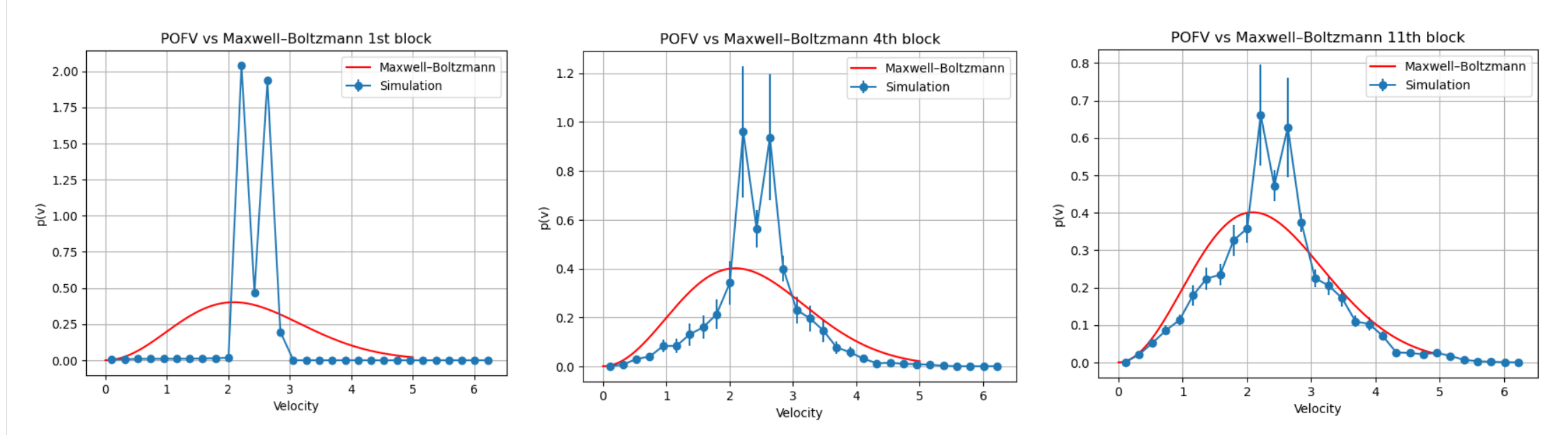

e, infine, la distribuzione all'equilibrio (blocco finale):

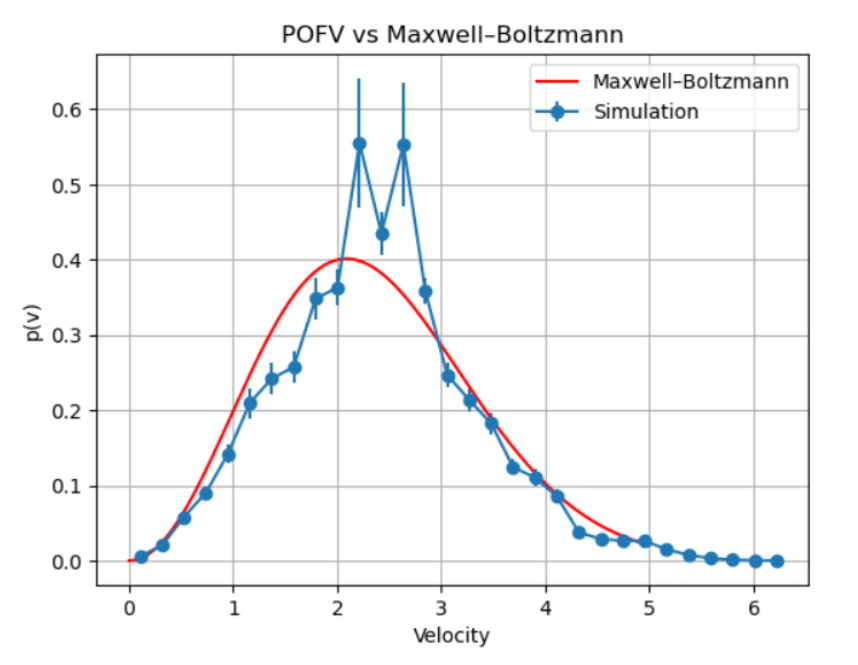

Conclusione: l'imposizione di uno stato iniziale a bassa entropia produce picchi artificiali nella distribuzione delle velocità: tutte le particelle si muovono inizialmente con lo stesso modulo della velocità (sono stati imposti moduli fissi), per cui la distribuzione non assume la forma di una campana ma presenta due picchi ben definiti. Con l'aumento dell'entropia, tali picchi si appiattiscono progressivamente, dimostrando che le particelle collidono tra loro e ridistribuiscono i propri momenti. Alla fine dell'evoluzione i due picchi risultano fortemente attenuati e la distribuzione si avvicina a quella di Maxwell-Boltzmann, pur senza coincidere perfettamente a causa di un piccolo residuo dovuto alla condizione iniziale di non equilibrio.

Nota: il programma è stato modificato affinché il file di configurazione letto sia *config.xyz* anziché *config.fcc*.


In [ ]:
# Istogramma a dispersione delle velocità
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

pofv = np.loadtxt(r"NSL_SIMULATOR\OUTPUT\pofv.dat")
temp = np.loadtxt(r"NSL_SIMULATOR\OUTPUT\temperature.dat")
T_eff = temp[-1, 2] # last value of the average

n_bins = 30

# Maxwell–Boltzmann teoric (3D)
vel = np.linspace(0, 5, 200)
m_b = 4 * np.pi * vel**2 * np.exp(-vel**2 / (2*T_eff))
m_b /= np.trapezoid(m_b, vel)  # to normalize

plt.errorbar(pofv[-n_bins:, 0],pofv[-n_bins:, 1],yerr=pofv[-n_bins:, 2], fmt='o-', label='Simulation')

plt.plot(vel, m_b, 'r-', label='Maxwell–Boltzmann')
plt.xlabel("Velocity")
plt.ylabel("p(v)")
plt.title("POFV vs Maxwell–Boltzmann")
plt.legend()
plt.grid(True)
plt.show()


plt.errorbar(pofv[11*n_bins:12*n_bins, 0],pofv[11*n_bins:12*n_bins, 1],yerr=pofv[11*n_bins:12*n_bins, 2], fmt='o-', label='Simulation')
plt.plot(vel, m_b, 'r-', label='Maxwell–Boltzmann')
plt.xlabel("Velocity")
plt.ylabel("p(v)")
plt.title("POFV vs Maxwell–Boltzmann 11th block")
plt.legend()
plt.grid(True)
plt.show()

plt.errorbar(pofv[4*n_bins:5*n_bins, 0],pofv[4*n_bins:5*n_bins, 1],yerr=pofv[4*n_bins:5*n_bins, 2], fmt='o-', label='Simulation')
plt.plot(vel, m_b, 'r-', label='Maxwell–Boltzmann')
plt.xlabel("Velocity")
plt.ylabel("p(v)")
plt.title("POFV vs Maxwell–Boltzmann 4th block")
plt.legend()
plt.grid(True)
plt.show()

plt.errorbar(pofv[0:n_bins, 0],pofv[0:n_bins, 1],yerr=pofv[0:n_bins, 2], fmt='o-', label='Simulation')
plt.plot(vel, m_b, 'r-', label='Maxwell–Boltzmann')
plt.xlabel("Velocity")
plt.ylabel("p(v)")
plt.title("POFV vs Maxwell–Boltzmann 1st block")
plt.legend()
plt.grid(True)
plt.show()

### Exercise 04.3
Nell'ultimo esercizio viene studiata la reversibilità del sistema. A tale scopo vengono scambiate le configurazioni finali ottenute nell'esercizio $04.2$: i file *config.xyz* e *conf-1.xyz* vengono rinominati invertendone i nomi, in modo da utilizzare come configurazione iniziale quella finale della simulazione precedente e tentare di ripercorrere il processo all'indietro.

Ci si aspetterebbe che il gas "torni indietro", cioè che il sistema ritorni alla configurazione iniziale a bassa entropia. Tuttavia, i risultati mostrano che il sistema rimane in uno stato gassoso caotico in equilibrio. La distribuzione delle velocità risulta addirittura ancora più vicina alla distribuzione teorica di Maxwell-Boltzmann:

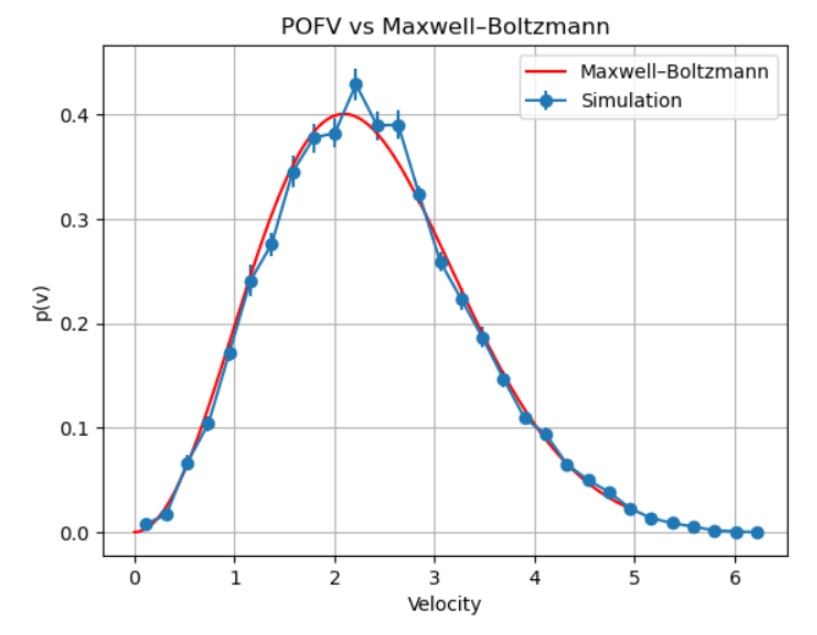


Per evidenziare questo comportamento, vengono confrontate l'energia potenziale e la temperatura ottenute nell'esercizio $04.2$ con quelle dell'esercizio $04.3$, ottenendo i seguenti grafici:

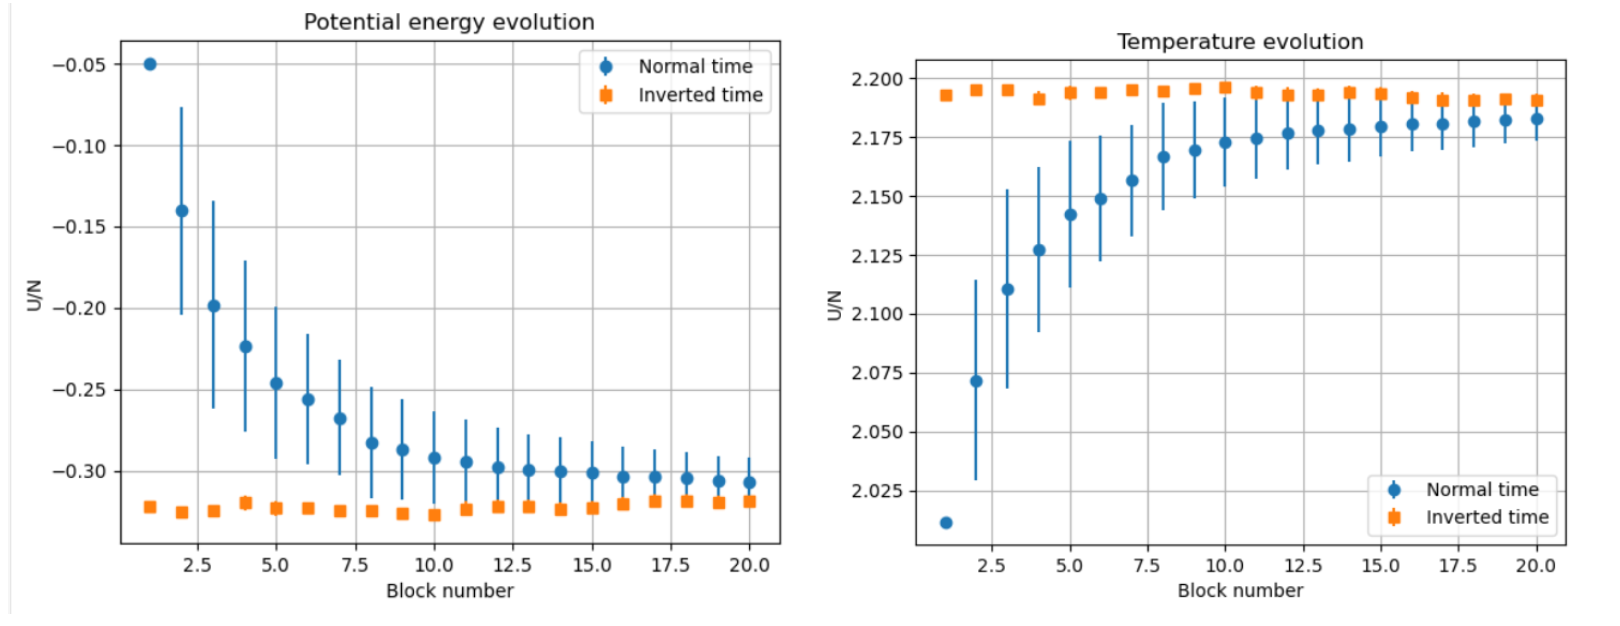

Che cosa si osserva? Il sistema tenta di ritornare allo stato iniziale, ma non ci riesce. In entrambi i grafici la curva arancione (corrispondente all'evoluzione con il tempo invertito) rimane praticamente costante, mantenendo la temperatura e l'energia potenziale raggiunte nell'esercizio $04.2$. Questo costituisce una chiara dimostrazione dell'irreversibilità del processo e di come il sistema rimanga intrappolato in uno stato di equilibrio gassoso a causa della natura caotica delle collisioni tra le particelle.

In [ ]:
# Inverted time
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

pot2 = np.loadtxt(r"NSL_SIMULATOR\OUTPUT\04.2\potential_energy.dat")
pot3 = np.loadtxt(r"NSL_SIMULATOR\OUTPUT\04.3\potential_energy.dat")

temp2 = np.loadtxt(r"NSL_SIMULATOR\OUTPUT\04.2\temperature.dat")
temp3 = np.loadtxt(r"NSL_SIMULATOR\OUTPUT\04.3\temperature.dat")

plt.errorbar(pot2[:,0],pot2[:,2],yerr=pot2[:,3], fmt='o', label='Normal time')
plt.errorbar(pot3[:,0],pot3[:,2],yerr=pot3[:,3], fmt='s', label='Inverted time')
plt.xlabel("Block number")
plt.ylabel("U/N")
plt.title("Potential energy evolution")
plt.legend()
plt.grid(True)
plt.show()

plt.errorbar(temp2[:,0],temp2[:,2],yerr=temp2[:,3], fmt='o', label='Normal time')
plt.errorbar(temp3[:,0],temp3[:,2],yerr=temp3[:,3], fmt='s', label='Inverted time')
plt.xlabel("Block number")
plt.ylabel("U/N")
plt.title("Temperature evolution")
plt.legend()
plt.grid(True)
plt.show()
